## Preliminaries

### Import statements

In [1]:
import os
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

### Global values

In [2]:
data_dir = "data"
plot_dir = "plot"

### Load tokens

In [3]:
token_file = os.path.join(data_dir, "tokens.tsv")
tokens = pd.read_csv(token_file, delimiter="\t", dtype=str)

### Select most frequent lemmas

In [4]:
# corpus-wide count for all non-punctuation lemmas, from most frequent to least
corpus_lemma_count = tokens["lemma"].value_counts()

# a list of the top lemmas
top_lemmas = corpus_lemma_count.head(100).index

# show results
display(corpus_lemma_count.loc[top_lemmas])

lemma
δέ        21339
καί       13671
ὁ          9589
τε         5574
ἐγώ        3783
          ...  
πέλω        530
τίθημι      530
ἄγω         525
σύν         520
βαίνω       519
Name: count, Length: 100, dtype: int64

## Authorship

### Define samples

In [5]:
# sample labels are just work title + book number
tokens["sample_id"] = (tokens["work"] + " " + tokens["pref"].fillna("")).str.strip()

### Tokens per sample

Distribution of book lengths in tokens

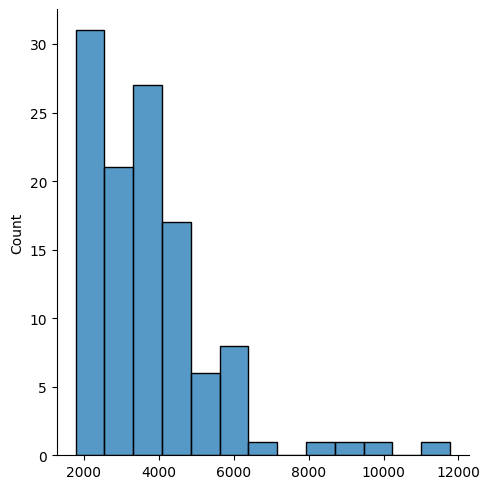

In [6]:
tokens_per_sample = tokens.groupby("sample_id").size()
sns.displot(tokens_per_sample)

### Generate feature vectors by book

In [7]:
# tally lemma counts
samples = pd.crosstab(
    tokens.loc[tokens["lemma"].isin(top_lemmas), "sample_id"],
    tokens.loc[tokens["lemma"].isin(top_lemmas), "lemma"],
)

# normalize as freq / 1000 words
samples = samples.div(tokens_per_sample, axis=0) * 1000

display(samples)

lemma,Διόνυσος,αἱρέω,αὐτός,βάλλω,βαίνω,γάρ,γαῖα,γε,δέ,δή,...,ἵστημι,ὀδυσσεύς,ὁ,ὄφρα,ὅδε,ὅς,ὅσος,ὅτε,ὑπό,ὡς
sample_id,,,,,,,,,,,,,,,,,,,,,
Argonautica 1,0.111595,1.339136,7.365249,1.450731,2.008704,6.137708,2.566678,1.673920,52.895882,4.240598,...,0.669568,0.000000,29.126214,2.231894,1.785515,7.030465,2.343488,2.678273,2.901462,7.142060
Argonautica 2,0.000000,1.412263,8.002825,1.647640,0.941509,6.708250,3.883724,1.412263,54.725197,5.295987,...,1.059197,0.000000,29.422149,0.706132,3.177592,6.590561,2.706838,2.471461,3.766035,7.179004
Argonautica 3,0.000000,1.564619,10.013560,1.251695,1.251695,5.006780,2.086158,2.503390,57.369354,4.172317,...,0.625848,0.000000,27.850214,1.356003,3.755085,5.736935,1.668927,2.712006,3.233545,9.492020
Argonautica 4,0.084926,1.273885,5.859873,2.208068,1.358811,6.539278,3.397028,1.358811,52.314225,5.265393,...,0.339703,0.000000,26.581741,1.953291,3.397028,8.067941,1.868365,2.717622,2.802548,6.878981
Dionysiaca 1,0.619195,0.000000,2.476780,0.619195,0.928793,3.715170,1.547988,0.928793,40.557276,0.309598,...,1.547988,0.000000,5.263158,1.857585,0.309598,0.928793,0.309598,1.857585,2.167183,4.953560
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Posthomerica 6,0.000000,1.330082,4.655287,2.660164,0.886721,6.650410,1.995123,2.438484,62.735535,3.990246,...,0.221680,0.443361,27.931722,0.443361,0.443361,7.758812,1.995123,2.216803,4.655287,10.640656
Posthomerica 7,0.000000,1.383126,5.532503,2.371073,1.185536,6.322861,1.580715,2.173484,54.929856,2.568662,...,0.197589,1.383126,22.920371,0.790358,0.197589,7.508398,1.975894,4.544556,5.730093,12.250543
Posthomerica 8,0.000000,0.884434,2.653302,3.537736,0.000000,8.254717,3.242925,3.832547,65.742925,2.063679,...,0.884434,0.294811,22.995283,0.294811,0.589623,9.139151,1.179245,2.358491,4.716981,11.792453


### Dimensionality reduction

In [8]:
model = PCA(n_components=3)
scaled = StandardScaler().fit_transform(samples)
pca = pd.DataFrame(model.fit_transform(scaled), columns=["PC1", "PC2", "PC3"])

## Author signal
### plot individual books

This is the plot that I might start with, showing how the different books cluster themselves according to author/work based on the most frequent words.


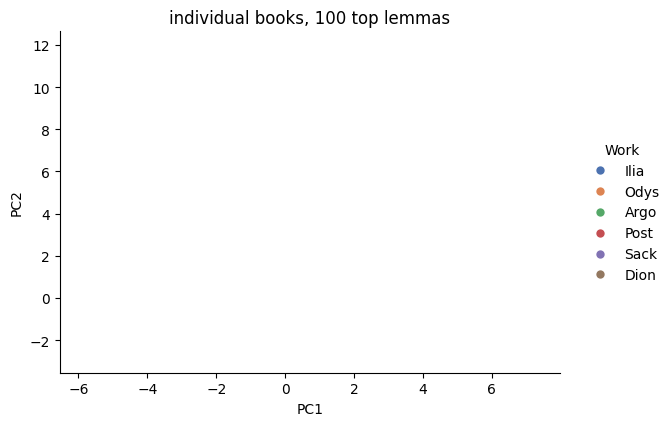

In [19]:
# Labels for legend: take first 4 chars of index (e.g. "Iliad" -> "Ilia")
short_label = samples.index.str.slice(0,4)

# Custom order for labels in the legend (top to bottom)
label_order = ["Ilia", "Odys", "Argo", "Post", "Sack", "Dion"]

# Plot using Seaborn
g = sns.relplot(data=pca,
    x = "PC1",
    y = "PC2",
    hue = short_label,        # color points by work
    hue_order = label_order,
    palette = "deep",         # seaborn color palette; try "muted", "bright", "colorblind", etc.
)

# Figure dimensions in inches (width, height)
g.figure.set_size_inches(7, 4)

# Set figure title
g.ax.set_title(f"individual books, {len(samples.columns)} top lemmas")

# Set legend heading
g._legend.set_title("Work")

# Export figure as png file
g.savefig(os.path.join(plot_dir, "auth_PCA_by_book.png"),
    # dpi=300,              # uncomment for higher resolution (default 100)
    # bbox_inches="tight",  # uncomment to trim whitespace around figure
)

plt.show()

## Speech vs. Narrative

This part shows the speech/narrative signal by averaging out authorship. We randomly sample 1000 tokens at a time from the corpus as a whole, according only to whether they are narrative or speech.

### Create new samples

In [10]:
# identify tokens spoken by characters/narrator
#  (omit Odysseus as Apologue narrator)
nr_mask = tokens["speaker"].isna()
sp_mask = tokens["speaker"].notna() & tokens["speaker"].ne("Odysseus-Apologue")

# default group is "other"
tokens["group"] = "oth"
tokens.loc[nr_mask, "group"] = "nar"
tokens.loc[sp_mask, "group"] = "spk"

# create samples
sample_size = 1000
for group in tokens["group"].unique():
    n_toks = sum(tokens["group"]==group)
    tokens.loc[tokens["group"]==group, "sample_id"] = np.random.permutation(n_toks) // sample_size
tokens["sample_id"] = tokens["group"] + "-" + tokens["sample_id"].map(str)

### Tokens per sample

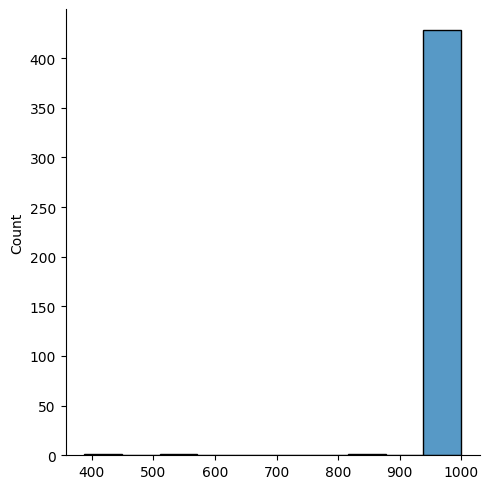

In [11]:
tokens_per_sample = tokens.groupby("sample_id").size()
sns.displot(tokens_per_sample)

### Calculate feature vectors for each sample

As in the author signal plot above, we're using the same top 1000 words.

In [13]:
# tally lemma counts
samples = pd.crosstab(
    tokens.loc[tokens["lemma"].isin(top_lemmas), "sample_id"],
    tokens.loc[tokens["lemma"].isin(top_lemmas), "lemma"],
)

# normalize as freq / 1000 words
samples = samples.div(tokens_per_sample, axis=0) * 1000

display(samples)

lemma,Διόνυσος,αἱρέω,αὐτός,βάλλω,βαίνω,γάρ,γαῖα,γε,δέ,δή,...,ἵστημι,ὀδυσσεύς,ὁ,ὄφρα,ὅδε,ὅς,ὅσος,ὅτε,ὑπό,ὡς
sample_id,,,,,,,,,,,,,,,,,,,,,
nar-0,2.0,1.0,3.0,1.0,1.0,4.0,1.0,0.0,66.0,0.0,...,1.0,3.0,29.0,1.0,1.0,8.0,0.0,1.0,5.0,8.0
nar-1,2.0,1.0,6.0,5.0,3.0,6.0,1.0,2.0,56.0,3.0,...,0.0,1.0,24.0,0.0,0.0,7.0,1.0,1.0,2.0,13.0
nar-10,1.0,1.0,4.0,1.0,2.0,6.0,0.0,0.0,48.0,4.0,...,2.0,1.0,35.0,0.0,0.0,6.0,0.0,5.0,0.0,12.0
nar-100,1.0,4.0,2.0,2.0,1.0,1.0,2.0,3.0,55.0,1.0,...,0.0,2.0,24.0,2.0,0.0,2.0,0.0,1.0,5.0,17.0
nar-101,2.0,0.0,3.0,3.0,1.0,5.0,2.0,3.0,65.0,0.0,...,1.0,4.0,27.0,0.0,0.0,11.0,2.0,0.0,5.0,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
spk-95,1.0,1.0,5.0,2.0,0.0,9.0,1.0,4.0,27.0,2.0,...,0.0,1.0,8.0,3.0,2.0,10.0,2.0,1.0,4.0,2.0
spk-96,1.0,0.0,8.0,5.0,0.0,16.0,2.0,4.0,29.0,4.0,...,0.0,1.0,14.0,5.0,6.0,10.0,0.0,3.0,2.0,9.0
spk-97,0.0,1.0,3.0,1.0,0.0,6.0,1.0,5.0,34.0,5.0,...,0.0,2.0,14.0,4.0,3.0,6.0,0.0,1.0,0.0,5.0


### Dimensionality reduction

In [14]:
model = PCA(n_components=3)
scaled = StandardScaler().fit_transform(samples)
pca = pd.DataFrame(model.fit_transform(scaled), columns=["PC1", "PC2", "PC3"])

### Plot

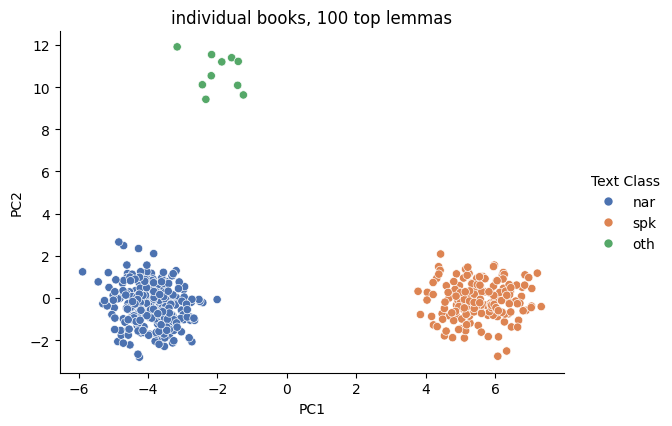

In [20]:
# Labels for legend: take first 3 chars of index
short_label = samples.index.str.slice(0,3)

# Custom order for labels in the legend (top to bottom)
label_order = ["nar", "spk", "oth"]

# Plot using Seaborn
g = sns.relplot(data=pca,
    x = "PC1",
    y = "PC2",
    hue = short_label,        # color points by work
    hue_order = label_order,
    palette = "deep",         # seaborn color palette; try "muted", "bright", "colorblind", etc.
)

# Figure dimensions in inches (width, height)
g.figure.set_size_inches(7, 4)

# Set figure title
g.ax.set_title(f"individual books, {len(samples.columns)} top lemmas")

# Set legend heading
g._legend.set_title("Text Class")

# Export figure as png file
g.savefig(os.path.join(plot_dir, "spk-nar_PCA_by_book.png"),
    # dpi=300,              # uncomment for higher resolution (default 100)
    # bbox_inches="tight",  # uncomment to trim whitespace around figure
)

plt.show()